This is a notebook for initial exploration of Goodreads data published by UCSD (2017). The fantasy/paranormal genre is used as a subset of the entire dataset.

- `goodreads_books_fantasy_paranormal.json.gz` - book metadata
- `goodreads_interactions_fantasy_paranormal.json.gz` — user-book interactions
- `goodreads_reviews_fantasy_paranormal.json.gz` — detailed review text

In [ ]:
%pip install pandas matplotlib seaborn tqdm

import gzip
import json
import os
import ast
from collections import Counter
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from tqdm.notebook import tqdm

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)
sns.set_theme(style='whitegrid', palette='muted')

In [ ]:
# you can change data_dir to wherever you saved the goodreads data!
data_dir = Path('/Users/krystalwu/Downloads/readradar/data')   

books_file = data_dir / 'goodreads_books_fantasy_paranormal.json.gz'
interactions_file = data_dir / 'goodreads_interactions_fantasy_paranormal.json.gz'
reviews_file = data_dir / 'goodreads_reviews_fantasy_paranormal.json.gz'

for f in [books_file, interactions_file, reviews_file]:
    exists = f.exists()
    size   = f'{f.stat().st_size / 1e6:.1f} MB' if exists else 'not found'
    print(f'{f.name:60s}  {size}')

goodreads_books_fantasy_paranormal.json.gz                    278.8 MB
goodreads_interactions_fantasy_paranormal.json.gz             2800.8 MB
goodreads_reviews_fantasy_paranormal.json.gz                  1259.1 MB


In [3]:
# these are helper functions
def load_json_gz(filepath, max_records=None, show_progress=True):
    """loads a .json.gz file (one JSON object per line) into a DF, then
    sets max_records to an integer to load only a sample."""
    records = []
    with gzip.open(filepath, 'rt', encoding='utf-8') as f:
        iterator = tqdm(f, desc=f'Loading {Path(filepath).name}') if show_progress else f
        for i, line in enumerate(iterator):
            if max_records and i >= max_records:
                break
            try:
                records.append(json.loads(line.strip()))
            except json.JSONDecodeError:
                pass
    return pd.DataFrame(records)


def field_coverage(df, top_n=40):
    """returns a df showing non-null rate and sample values per column."""
    rows = []
    for col in df.columns:
        non_null  = df[col].notna().sum()
        # also count empty strings and empty lists as 'empty'
        non_empty = df[col].apply(
            lambda x: x not in [None, '', [], {}, 'None', 'none']
            if not isinstance(x, float) else not np.isnan(x)
        ).sum()
        sample = df[col].dropna().iloc[0] if non_null > 0 else None
        rows.append({
            'column':      col,
            'dtype':       str(df[col].dtype),
            'non_null_%':  round(100 * non_null  / len(df), 1),
            'non_empty_%': round(100 * non_empty / len(df), 1),
            'sample_value': str(sample)[:80]
        })
    return pd.DataFrame(rows).sort_values('non_empty_%', ascending=False).head(top_n)


def peek(df, n=3):
    """displays first n rows transposed for readability."""
    return df.head(n).T


print('Helper functions defined.')

Helper functions defined.


### (1) Books Metadata

In [5]:
# start with 5000
books_sample = load_json_gz(books_file, max_records=5_000)
print(f'Sample shape: {books_sample.shape}')
books_sample.head(2).T

Loading goodreads_books_fantasy_paranormal.json.gz: 0it [00:00, ?it/s]

Sample shape: (5000, 29)


,0,1
isbn,,1934876569
text_reviews_count,7,6
series,[189911],[151854]
country_code,US,US
language_code,eng,
popular_shelves,"[{'count': '58', 'name': 'to-read'}, {'count': '15', 'name': 'fantasy'}, {'c...","[{'count': '515', 'name': 'to-read'}, {'count': '25', 'name': 'fantasy'}, {'..."
asin,B00071IKUY,
is_ebook,false,false
average_rating,4.03,4.22
kindle_asin,,


In [6]:
field_coverage(books_sample)

,column,dtype,non_null_%,non_empty_%,sample_value
14,authors,object,100.0,100.0,"[{'author_id': '10333', 'role': ''}]"
13,link,object,100.0,100.0,https://www.goodreads.com/book/show/7327624-the-unschooled-wizard
27,title,object,100.0,100.0,"The Unschooled Wizard (Sun Wolf and Starhawk, #1-2)"
26,work_id,object,100.0,100.0,8948723
25,ratings_count,object,100.0,100.0,140
24,book_id,object,100.0,100.0,7327624
23,image_url,object,100.0,100.0,https://images.gr-assets.com/books/1304100136m/7327624.jpg
22,url,object,100.0,100.0,https://www.goodreads.com/book/show/7327624-the-unschooled-wizard
1,text_reviews_count,object,100.0,100.0,7
28,title_without_series,object,100.0,100.0,"The Unschooled Wizard (Sun Wolf and Starhawk, #1-2)"


In [8]:
# try loading full book file
books = load_json_gz(books_file)
print(f'Full books shape: {books.shape}')

Loading goodreads_books_fantasy_paranormal.json.gz: 0it [00:00, ?it/s]

Full books shape: (258585, 29)


In [9]:
print('All columns:\n', books.columns.tolist())

All columns:
 ['isbn', 'text_reviews_count', 'series', 'country_code', 'language_code', 'popular_shelves', 'asin', 'is_ebook', 'average_rating', 'kindle_asin', 'similar_books', 'description', 'format', 'link', 'authors', 'publisher', 'num_pages', 'publication_day', 'isbn13', 'publication_month', 'edition_information', 'publication_year', 'url', 'image_url', 'book_id', 'ratings_count', 'work_id', 'title', 'title_without_series']


In [10]:
field_coverage(books, top_n=50)

,column,dtype,non_null_%,non_empty_%,sample_value
14,authors,object,100.0,100.0,"[{'author_id': '10333', 'role': ''}]"
13,link,object,100.0,100.0,https://www.goodreads.com/book/show/7327624-the-unschooled-wizard
27,title,object,100.0,100.0,"The Unschooled Wizard (Sun Wolf and Starhawk, #1-2)"
26,work_id,object,100.0,100.0,8948723
25,ratings_count,object,100.0,100.0,140
24,book_id,object,100.0,100.0,7327624
23,image_url,object,100.0,100.0,https://images.gr-assets.com/books/1304100136m/7327624.jpg
22,url,object,100.0,100.0,https://www.goodreads.com/book/show/7327624-the-unschooled-wizard
1,text_reviews_count,object,100.0,100.0,7
28,title_without_series,object,100.0,100.0,"The Unschooled Wizard (Sun Wolf and Starhawk, #1-2)"


In [11]:
print('Duplicate book_ids:', books['book_id'].duplicated().sum())
print('Sample book_ids:', books['book_id'].head(5).tolist())

Duplicate book_ids: 0
Sample book_ids: ['7327624', '6066812', '33394837', '12182387', '29074693']


Ratings distribution

In [12]:
for col in ['average_rating', 'ratings_count', 'text_reviews_count', 'num_pages']:
    if col in books.columns:
        books[col] = pd.to_numeric(books[col], errors='coerce')

books[['average_rating', 'ratings_count', 'text_reviews_count', 'num_pages']].describe()

,average_rating,ratings_count,text_reviews_count,num_pages
count,258585.000000,2.585850e+05,258585.00000,176344.000000
mean,3.941337,8.404962e+02,48.66539,308.572234
std,0.364376,1.917309e+04,534.42068,285.858104
min,0.000000,0.000000e+00,0.00000,0.000000
25%,3.730000,1.300000e+01,3.00000,192.000000
50%,3.960000,4.200000e+01,7.00000,300.000000
75%,4.180000,1.560000e+02,19.00000,387.000000
max,5.000000,4.765497e+06,90766.00000,82000.000000


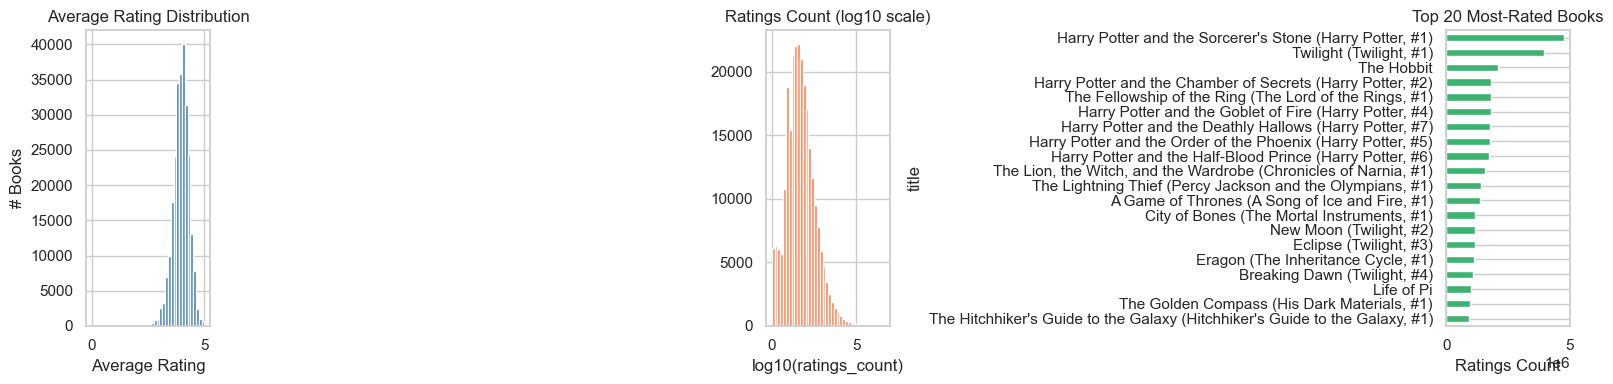

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# average rating distribution
books['average_rating'].dropna().hist(bins=40, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Average Rating Distribution')
axes[0].set_xlabel('Average Rating')
axes[0].set_ylabel('# Books')

# ratings count, using log scale
rc = books['ratings_count'].dropna()
rc[rc > 0].apply(np.log10).hist(bins=40, ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Ratings Count (log10 scale)')
axes[1].set_xlabel('log10(ratings_count)')

# top 20 most rated books here
top20 = books.nlargest(20, 'ratings_count')[['title', 'ratings_count']].set_index('title')
top20.plot(kind='barh', ax=axes[2], legend=False, color='mediumseagreen')
axes[2].set_title('Top 20 Most-Rated Books')
axes[2].set_xlabel('Ratings Count')
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

(that's a lot of YA fantasy series ratings, lol. can't blame them)

Authors & shelves

In [14]:
if 'authors' in books.columns:
    print('Sample authors field:')
    print(books['authors'].dropna().iloc[0])

    # count books with at least one author listed
    has_author = books['authors'].apply(
        lambda x: isinstance(x, list) and len(x) > 0
    )
    print(f'\nBooks with author data: {has_author.sum():,} ({100*has_author.mean():.1f}%)')

Sample authors field:
[{'author_id': '10333', 'role': ''}]

Books with author data: 258,583 (100.0%)


In [15]:
# popular shelves — most useful proxy for themes/genres
if 'popular_shelves' in books.columns:
    print('Sample popular_shelves:')
    print(books['popular_shelves'].dropna().iloc[0])

    # flatten all shelf names and count frequency
    all_shelves = []
    for shelves in books['popular_shelves'].dropna():
        if isinstance(shelves, list):
            for s in shelves:
                if isinstance(s, dict) and 'name' in s:
                    all_shelves.append(s['name'])

    shelf_counts = Counter(all_shelves)
    top_shelves  = pd.DataFrame(shelf_counts.most_common(30), columns=['shelf', 'count'])
    print('\nTop 30 shelf names:')
    print(top_shelves.to_string(index=False))

Sample popular_shelves:
[{'count': '58', 'name': 'to-read'}, {'count': '15', 'name': 'fantasy'}, {'count': '6', 'name': 'fiction'}, {'count': '5', 'name': 'owned'}, {'count': '3', 'name': 'hardcover'}, {'count': '2', 'name': 'shelfari-favorites'}, {'count': '2', 'name': 'series'}, {'count': '1', 'name': 'might-read'}, {'count': '1', 'name': 'dnf-d'}, {'count': '1', 'name': 'hambly-barbara'}, {'count': '1', 'name': 'strong-females'}, {'count': '1', 'name': 'first-in-series'}, {'count': '1', 'name': 'fantasy-sword-sorcery'}, {'count': '1', 'name': 'no-thanks-series-collections-boxes'}, {'count': '1', 'name': 'fantasy-all'}, {'count': '1', 'name': 'entertaining-but-limited'}, {'count': '1', 'name': 'kate-own'}, {'count': '1', 'name': 'fantasy-epic'}, {'count': '1', 'name': 'e-book'}, {'count': '1', 'name': 'compliation'}, {'count': '1', 'name': 'my-books'}, {'count': '1', 'name': 'books-i-own-but-have-not-read'}, {'count': '1', 'name': 'everything-owned'}, {'count': '1', 'name': 'books-to

note that genres overlap!

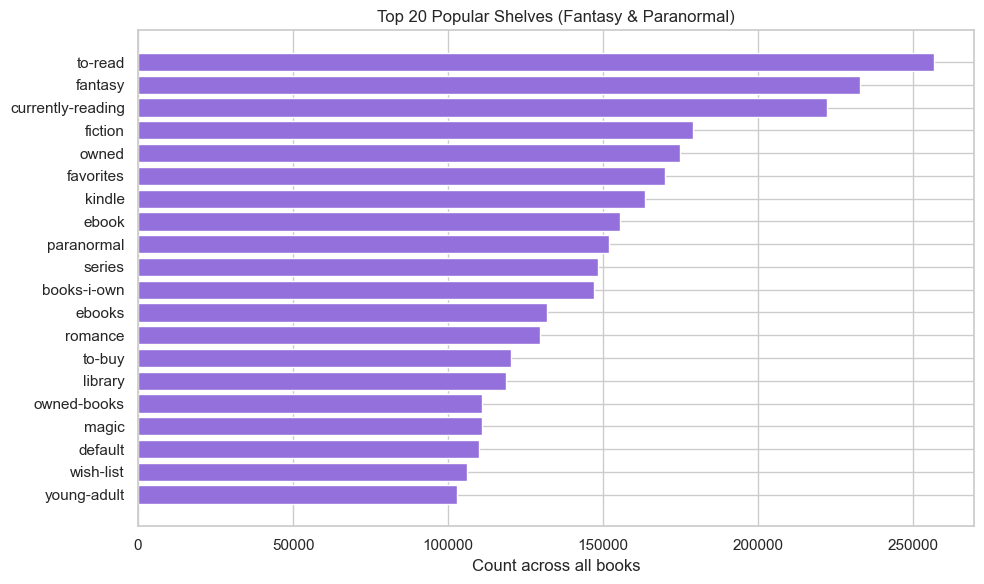

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_shelves['shelf'][:20][::-1], top_shelves['count'][:20][::-1], color='mediumpurple')
ax.set_title('Top 20 Popular Shelves (Fantasy & Paranormal)')
ax.set_xlabel('Count across all books')
plt.tight_layout()
plt.show()

In [17]:
# description length: important for theme search
if 'description' in books.columns:
    books['desc_len'] = books['description'].fillna('').str.len()
    print(books['desc_len'].describe())
    print(f"\nBooks with non-empty description: {(books['desc_len'] > 0).sum():,} ({100*(books['desc_len']>0).mean():.1f}%)")

    # sample a long description to see what they look like
    sample_desc = books[books['desc_len'] > 200]['description'].iloc[0]
    print('\n--- Sample description ---')
    print(sample_desc[:500])

count    258585.000000
mean        780.377095
std         512.606169
min           0.000000
25%         471.000000
50%         759.000000
75%        1024.000000
max       24812.000000
Name: desc_len, dtype: float64

Books with non-empty description: 237,881 (92.0%)

--- Sample description ---
To Kara's astonishment, she discovers that a portal has opened in her bedroom closet and two goblins have fallen through! They refuse to return to the fairy realms and be drafted for an impending war. In an attempt to roust the pesky creatures, Kara falls through the portal, smack into the middle of a huge war. Kara meets Queen Selinda, who appoints Kara as a Fairy Princess and assigns her an impossible task: to put an end to the war using her diplomatic skills.
All's Fairy In Love And War is th


### (2) User-book interactions

In [18]:
interaction_sample_size = 500_000

interactions_sample = load_json_gz(interactions_file, max_records=interaction_sample_size)
print(f'Sample shape: {interactions_sample.shape}')
interactions_sample.head(3).T

Loading goodreads_interactions_fantasy_paranormal.json.gz: 0it [00:00, ?it/s]

Sample shape: (500000, 10)


,0,1,2
user_id,8842281e1d1347389f2ab93d60773d4d,8842281e1d1347389f2ab93d60773d4d,8842281e1d1347389f2ab93d60773d4d
book_id,19161852,18245960,32075825
review_id,4443cb6883624c3772625ef5b7b4e138,dfdbb7b0eb5a7e4c26d59a937e2e5feb,11ffeb4204d7421f716a8f91c190ef2c
is_read,False,True,False
rating,0,5,0
review_text_incomplete,,"This is a special book. It started slow for about the first third, then in t...",
date_added,Fri Sep 08 10:44:24 -0700 2017,Sun Jul 30 07:44:10 -0700 2017,Wed May 31 06:41:50 -0700 2017
date_updated,Fri Sep 08 10:44:24 -0700 2017,Wed Aug 30 00:00:26 -0700 2017,Wed May 31 06:41:51 -0700 2017
read_at,,Sat Aug 26 12:05:52 -0700 2017,
started_at,,Tue Aug 15 13:23:18 -0700 2017,


In [19]:
field_coverage(interactions_sample)

,column,dtype,non_null_%,non_empty_%,sample_value
0,user_id,object,100.0,100.0,8842281e1d1347389f2ab93d60773d4d
1,book_id,object,100.0,100.0,19161852
2,review_id,object,100.0,100.0,4443cb6883624c3772625ef5b7b4e138
3,is_read,bool,100.0,100.0,False
4,rating,int64,100.0,100.0,0
6,date_added,object,100.0,100.0,Fri Sep 08 10:44:24 -0700 2017
7,date_updated,object,100.0,100.0,Fri Sep 08 10:44:24 -0700 2017
8,read_at,object,100.0,23.2,
9,started_at,object,100.0,17.5,
5,review_text_incomplete,object,100.0,7.2,


In [20]:
interactions_sample['rating'] = pd.to_numeric(interactions_sample['rating'], errors='coerce')

print('Rating value counts (includes 0 = no explicit rating):')
print(interactions_sample['rating'].value_counts().sort_index())

# fraction with explicit ratings (1-5)
explicit = interactions_sample['rating'].between(1, 5)
print(f'\nExplicit ratings (1-5): {explicit.sum():,} ({100*explicit.mean():.1f}% of interactions)')

Rating value counts (includes 0 = no explicit rating):
rating
0    250257
1      4658
2     14054
3     53389
4     91221
5     86421
Name: count, dtype: int64

Explicit ratings (1-5): 249,743 (49.9% of interactions)


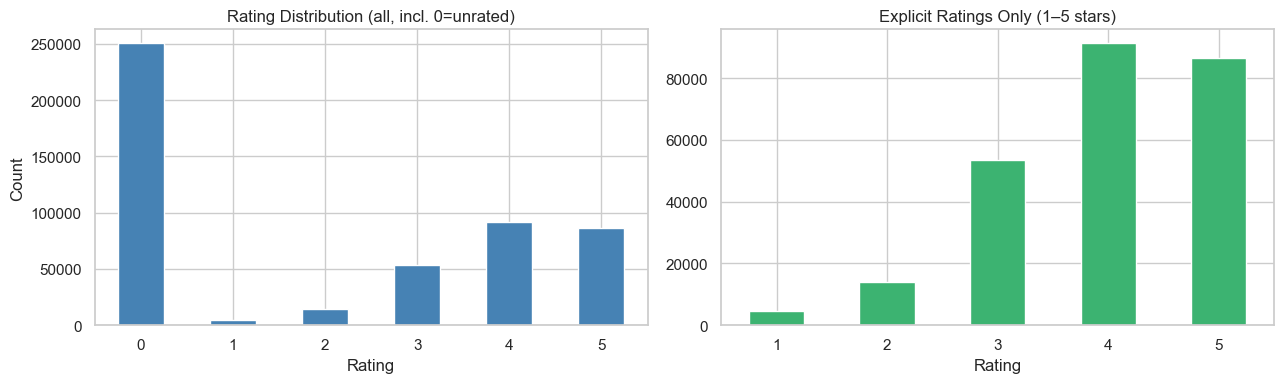

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# All ratings including 0
interactions_sample['rating'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].set_title('Rating Distribution (all, incl. 0=unrated)')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Only explicit 1-5 ratings
interactions_sample[explicit]['rating'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color='mediumseagreen', edgecolor='white'
)
axes[1].set_title('Explicit Ratings Only (1–5 stars)')
axes[1].set_xlabel('Rating')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [22]:
# Shelf / is_read breakdown
if 'is_read' in interactions_sample.columns:
    print('is_read value counts:')
    print(interactions_sample['is_read'].value_counts())

if 'shelves' in interactions_sample.columns:
    print('\nSample shelves:')
    print(interactions_sample['shelves'].dropna().head(5).tolist())

is_read value counts:
is_read
True     265605
False    234395
Name: count, dtype: int64


In [23]:
user_counts = interactions_sample.groupby('user_id').size()
book_counts = interactions_sample.groupby('book_id').size()

print('Interactions per user:')
print(user_counts.describe())
print('\nInteractions per book:')
print(book_counts.describe())

Interactions per user:
count    4318.000000
mean      115.794349
std       209.813497
min         1.000000
25%        17.000000
50%        47.000000
75%       124.000000
max      3948.000000
dtype: float64

Interactions per book:
count    79016.000000
mean         6.327832
std         31.922119
min          1.000000
25%          1.000000
50%          2.000000
75%          4.000000
max       2174.000000
dtype: float64


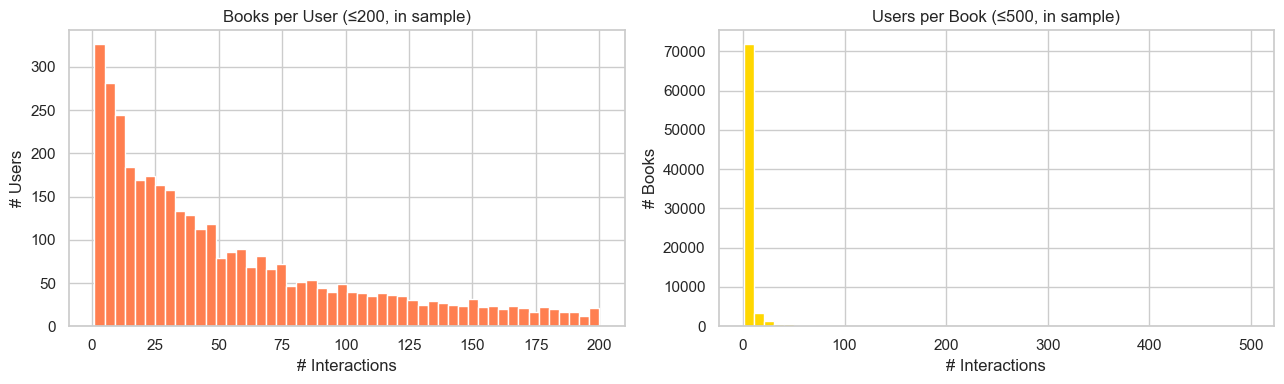

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

user_counts[user_counts <= 200].hist(bins=50, ax=axes[0], color='coral', edgecolor='white')
axes[0].set_title('Books per User (≤200, in sample)')
axes[0].set_xlabel('# Interactions')
axes[0].set_ylabel('# Users')

book_counts[book_counts <= 500].hist(bins=50, ax=axes[1], color='gold', edgecolor='white')
axes[1].set_title('Users per Book (≤500, in sample)')
axes[1].set_xlabel('# Interactions')
axes[1].set_ylabel('# Books')

plt.tight_layout()
plt.show()

In [25]:
# sparsity of user-item matrix
n_users = interactions_sample['user_id'].nunique()
n_books = interactions_sample['book_id'].nunique()
n_interactions = len(interactions_sample)
sparsity = 1 - n_interactions / (n_users * n_books)

print(f'Unique users  : {n_users:>10,}')
print(f'Unique books  : {n_books:>10,}')
print(f'Interactions  : {n_interactions:>10,}')
print(f'Matrix density: {100*(1-sparsity):.4f}%  (sparsity: {sparsity:.6f})')

Unique users  :      4,318
Unique books  :     79,016
Interactions  :    500,000
Matrix density: 0.1465%  (sparsity: 0.998535)


In [26]:
# this is a good proxy for the controversy score
# for controversy scoring, we want books with POLARISING ratings:
# lots of 1s AND lots of 5s (bimodal) vs books with mostly 3s (boring consensus)

rated = interactions_sample[explicit].copy()

book_stats = rated.groupby('book_id').agg(
    mean_rating   = ('rating', 'mean'),
    std_rating    = ('rating', 'std'),
    n_ratings     = ('rating', 'count'),
    pct_1star     = ('rating', lambda x: (x == 1).mean()),
    pct_5star     = ('rating', lambda x: (x == 5).mean()),
).reset_index()

# simple controversy score: std * (pct_1star + pct_5star) — high if bimodal
book_stats['controversy_score'] = (
    book_stats['std_rating'] * (book_stats['pct_1star'] + book_stats['pct_5star'])
)

# only trust scores for books with enough ratings
MIN_RATINGS = 50
reliable = book_stats[book_stats['n_ratings'] >= MIN_RATINGS].copy()

print(f'Books with ≥{MIN_RATINGS} ratings in sample: {len(reliable):,}')
print('\nTop 15 most controversial:')
top_controversial = reliable.nlargest(15, 'controversy_score').merge(
    books[['book_id', 'title']].astype({'book_id': str}),
    on='book_id', how='left'
)
print(top_controversial[['title', 'mean_rating', 'std_rating', 'n_ratings',
                          'pct_1star', 'pct_5star', 'controversy_score']].to_string(index=False))

Books with ≥50 ratings in sample: 700

Top 15 most controversial:
                                                      title  mean_rating  std_rating  n_ratings  pct_1star  pct_5star  controversy_score
                                     Dark Prince (Dark, #1)     3.490909    1.359095         55   0.127273   0.345455           0.642481
                                  Acheron (Dark-Hunter #14)     4.490909    0.879241         55   0.018182   0.690909           0.623461
                   Harry Potter Boxset (Harry Potter, #1-7)     4.659722    0.767916        144   0.020833   0.770833           0.607934
                     A Memory of Light (Wheel of Time, #14)     4.600000    0.786607         65   0.000000   0.738462           0.580879
                                    Elixir (Covenant, #3.5)     4.360000    0.942424         50   0.020000   0.580000           0.565454
                         The Iron Knight (The Iron Fey, #4)     4.253968    1.015497         63   0.031746   0.5

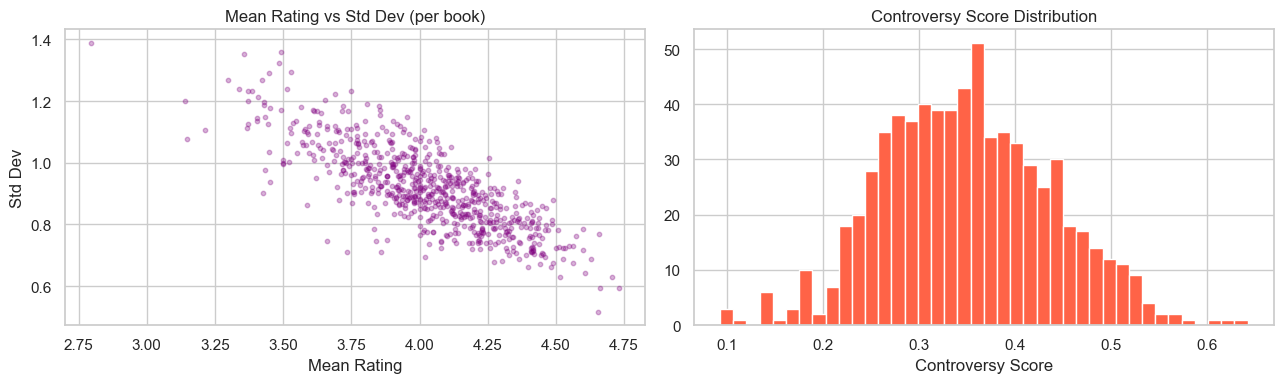

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(
    reliable['mean_rating'], reliable['std_rating'],
    alpha=0.3, s=10, color='purple'
)
axes[0].set_title('Mean Rating vs Std Dev (per book)')
axes[0].set_xlabel('Mean Rating')
axes[0].set_ylabel('Std Dev')

reliable['controversy_score'].hist(bins=40, ax=axes[1], color='tomato', edgecolor='white')
axes[1].set_title('Controversy Score Distribution')
axes[1].set_xlabel('Controversy Score')

plt.tight_layout()
plt.show()

### (3) User reviews

In [28]:
review_sample_size = 100_000

reviews_sample = load_json_gz(reviews_file, max_records=review_sample_size)
print(f'Sample shape: {reviews_sample.shape}')
reviews_sample.head(2).T

Loading goodreads_reviews_fantasy_paranormal.json.gz: 0it [00:00, ?it/s]

Sample shape: (100000, 11)


,0,1
user_id,8842281e1d1347389f2ab93d60773d4d,8842281e1d1347389f2ab93d60773d4d
book_id,18245960,5577844
review_id,dfdbb7b0eb5a7e4c26d59a937e2e5feb,52c8ac49496c153e4a97161e36b2db55
rating,5,5
review_text,"This is a special book. It started slow for about the first third, then in t...",A beautiful story. Neil Gaiman is truly a unique storyteller. I did a combo ...
date_added,Sun Jul 30 07:44:10 -0700 2017,Wed Sep 24 09:29:29 -0700 2014
date_updated,Wed Aug 30 00:00:26 -0700 2017,Wed Oct 01 00:31:56 -0700 2014
read_at,Sat Aug 26 12:05:52 -0700 2017,Tue Sep 30 00:00:00 -0700 2014
started_at,Tue Aug 15 13:23:18 -0700 2017,Sun Sep 21 00:00:00 -0700 2014
n_votes,28,5


In [29]:
field_coverage(reviews_sample)

,column,dtype,non_null_%,non_empty_%,sample_value
0,user_id,object,100.0,100.0,8842281e1d1347389f2ab93d60773d4d
1,book_id,object,100.0,100.0,18245960
2,review_id,object,100.0,100.0,dfdbb7b0eb5a7e4c26d59a937e2e5feb
3,rating,int64,100.0,100.0,5
5,date_added,object,100.0,100.0,Sun Jul 30 07:44:10 -0700 2017
6,date_updated,object,100.0,100.0,Wed Aug 30 00:00:26 -0700 2017
9,n_votes,int64,100.0,100.0,28
10,n_comments,int64,100.0,100.0,1
4,review_text,object,100.0,99.9,"This is a special book. It started slow for about the first third, then in t..."
7,read_at,object,100.0,84.8,Sat Aug 26 12:05:52 -0700 2017


In [30]:
reviews_sample['review_text'] = reviews_sample['review_text'].fillna('')
reviews_sample['text_len'] = reviews_sample['review_text'].str.len()
reviews_sample['word_count'] = reviews_sample['review_text'].str.split().str.len()

print('Review length (chars):')
print(reviews_sample['text_len'].describe())
print('\nWord count:')
print(reviews_sample['word_count'].describe())

# % with non-trivial review text
non_trivial = (reviews_sample['word_count'] >= 10).mean()
print(f'\nReviews with ≥10 words: {100*non_trivial:.1f}%')

Review length (chars):
count    100000.000000
mean        726.282520
std        1006.807809
min           0.000000
25%         135.000000
50%         363.000000
75%         920.000000
max       20009.000000
Name: text_len, dtype: float64

Word count:
count    100000.000000
mean        131.696170
std         180.187421
min           0.000000
25%          25.000000
50%          67.000000
75%         168.000000
max        3580.000000
Name: word_count, dtype: float64

Reviews with ≥10 words: 89.3%


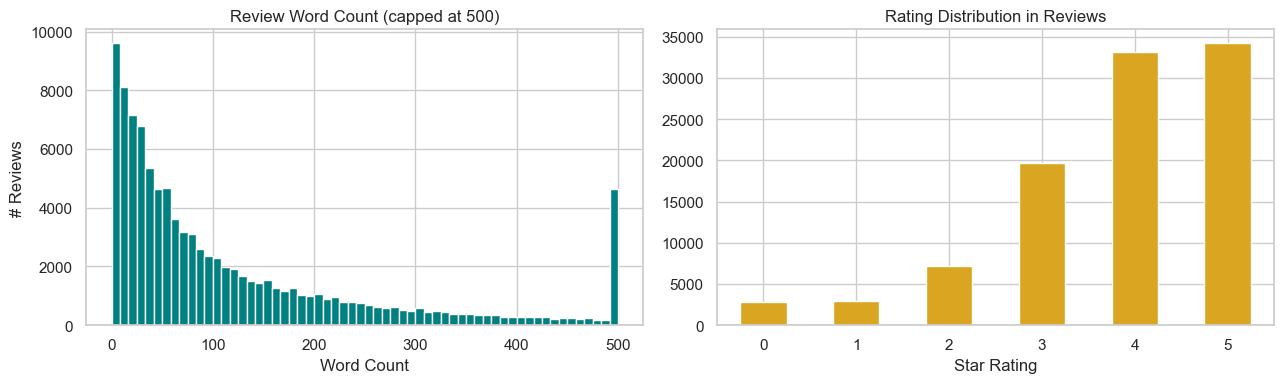

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

reviews_sample['word_count'].clip(upper=500).hist(
    bins=60, ax=axes[0], color='teal', edgecolor='white'
)
axes[0].set_title('Review Word Count (capped at 500)')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('# Reviews')

# rating distribution in reviews
if 'rating' in reviews_sample.columns:
    reviews_sample['rating'] = pd.to_numeric(reviews_sample['rating'], errors='coerce')
    reviews_sample['rating'].value_counts().sort_index().plot(
        kind='bar', ax=axes[1], color='goldenrod', edgecolor='white'
    )
    axes[1].set_title('Rating Distribution in Reviews')
    axes[1].set_xlabel('Star Rating')
    axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [32]:
# spoiler flag. this is useful for filtering
if 'spoiler_flag' in reviews_sample.columns or 'spoiler' in reviews_sample.columns:
    spoiler_col = 'spoiler_flag' if 'spoiler_flag' in reviews_sample.columns else 'spoiler'
    print('Spoiler flag distribution:')
    print(reviews_sample[spoiler_col].value_counts())

# date coverage
for date_col in ['date_added', 'date_updated', 'started_at', 'read_at']:
    if date_col in reviews_sample.columns:
        non_null = reviews_sample[date_col].notna().sum()
        print(f'{date_col}: {non_null:,} non-null  sample={reviews_sample[date_col].dropna().iloc[0] if non_null > 0 else None}')

date_added: 100,000 non-null  sample=Sun Jul 30 07:44:10 -0700 2017
date_updated: 100,000 non-null  sample=Wed Aug 30 00:00:26 -0700 2017
started_at: 100,000 non-null  sample=Tue Aug 15 13:23:18 -0700 2017
read_at: 100,000 non-null  sample=Sat Aug 26 12:05:52 -0700 2017


In [33]:
# print 3 sample reviews to get a feel for the text
print('=== SAMPLE REVIEWS ===\n')
sample_rev = reviews_sample[reviews_sample['word_count'] > 50].sample(3, random_state=42)
for _, row in sample_rev.iterrows():
    print(f"Book ID : {row.get('book_id', 'N/A')}")
    print(f"Rating  : {row.get('rating', 'N/A')}")
    print(f"Review  : {str(row['review_text'])[:400]}")
    print('-' * 60)

=== SAMPLE REVIEWS ===

Book ID : 10488165
Rating  : 3
Review  : Sugar Maple...uma vila habituada pelos descendentes dos seres oprimidos que fugiram de Salem durante os Julgamentos das Bruxas: vampiros, fadas, selkies, duendes, trolls, lobisomens, feiticeiras...e Chloe. 
 Mas desta vez, Chloe ja nao esta sozinha, em <<Feiticos de Amor>> Chloe apaixonou-se, e foi correspondida a 100%, pelo novo policia da vila, Luke, que optou por ficar em Sugar Maple, de livre 
------------------------------------------------------------
Book ID : 4467497
Rating  : 4
Review  : Menyesal sekali baru membaca sekarang. 
 Buku ini gelap, dengan tata bahasa sangat indah. Sebagian besar pembaca mengaitkannya pada dekonstruksi terhadap dongeng, tetapi menurut saya Connolly malah mengingatkan kita akan dongeng keluaran pertama, yang belum disamarkan oleh mimpi-mimpi ciptaan Disney. Sleeping Beauty versi Connoly sama gelapnya dengan versi Basile. Banyak pula kontras-kontras image
--------------------------------

In [34]:
book_ids_meta         = set(books['book_id'].astype(str))
book_ids_interactions = set(interactions_sample['book_id'].astype(str))
book_ids_reviews      = set(reviews_sample['book_id'].astype(str))

print(f'Books in metadata           : {len(book_ids_meta):>10,}')
print(f'Books in interactions sample: {len(book_ids_interactions):>10,}')
print(f'Books in reviews sample     : {len(book_ids_reviews):>10,}')
print()
print(f'Interactions ∩ metadata     : {len(book_ids_interactions & book_ids_meta):>10,}')
print(f'Reviews ∩ metadata          : {len(book_ids_reviews & book_ids_meta):>10,}')
print(f'All three                   : {len(book_ids_interactions & book_ids_reviews & book_ids_meta):>10,}')

Books in metadata           :    258,585
Books in interactions sample:     79,016
Books in reviews sample     :     40,110

Interactions ∩ metadata     :     79,016
Reviews ∩ metadata          :     40,110
All three                   :     30,679


In [35]:
# ISBNs are the bridge to Open Library's API
# Open Library lookup: https://openlibrary.org/api/books?bibkeys=ISBN:<isbn>&format=json

has_isbn = books['isbn'].notna() & (books['isbn'] != '') & (books['isbn'] != 'None')
has_isbn13 = books['isbn13'].notna() & (books['isbn13'] != '') & (books['isbn13'] != 'None')
has_either = has_isbn | has_isbn13

print(f'Books with isbn   : {has_isbn.sum():>8,} ({100*has_isbn.mean():.1f}%)')
print(f'Books with isbn13 : {has_isbn13.sum():>8,} ({100*has_isbn13.mean():.1f}%)')
print(f'Books with either : {has_either.sum():>8,} ({100*has_either.mean():.1f}%)')
print()
print('NOTE: Books without ISBN will require title+author fuzzy matching to Open Library.')

# some sample ISBNs for testing OL API
sample_isbns = books[has_isbn]['isbn'].dropna().head(5).tolist()
print('\nSample ISBNs for Open Library testing:')
for isbn in sample_isbns:
    print(f'  https://openlibrary.org/api/books?bibkeys=ISBN:{isbn}&format=json&jscmd=data')

Books with isbn   :  129,038 (49.9%)
Books with isbn13 :  157,875 (61.1%)
Books with either :  161,388 (62.4%)

NOTE: Books without ISBN will require title+author fuzzy matching to Open Library.

Sample ISBNs for Open Library testing:
  https://openlibrary.org/api/books?bibkeys=ISBN:1934876569&format=json&jscmd=data
  https://openlibrary.org/api/books?bibkeys=ISBN:0698143760&format=json&jscmd=data
  https://openlibrary.org/api/books?bibkeys=ISBN:0451460022&format=json&jscmd=data
  https://openlibrary.org/api/books?bibkeys=ISBN:0765313286&format=json&jscmd=data
  https://openlibrary.org/api/books?bibkeys=ISBN:1406346950&format=json&jscmd=data


### (idk what number to put here) Streamlit testing 

a small subset of the small subset (lol) for a really basic streamlit app prototype

In [36]:
# logic for filtering down to a high-quality subset for theme/genre analysis and controversy scoring
# 1. take the top 5 000 most-rated books (popularity ensures data richness)
# 2. keep only interactions for those books
# 3. keep only users with 5 or more interactions (active users)
# 4. keep reviews for those books

top_books = 5_000
min_user_interactions = 5

# step 1: top books by ratings_count
top_books = (
    books[books['ratings_count'] > 0]
    .nlargest(top_books, 'ratings_count')
    [['book_id', 'title', 'average_rating', 'ratings_count',
      'description', 'isbn', 'isbn13', 'authors', 'popular_shelves']]
    .copy()
)
top_book_ids = set(top_books['book_id'].astype(str))
print(f'Top {top_books} books selected.')

# step 2: interactions for those books (from sample)
proto_interactions = interactions_sample[
    interactions_sample['book_id'].astype(str).isin(top_book_ids)
].copy()
print(f'Interactions for top books (from sample): {len(proto_interactions):,}')

# step 3: filter to active users
user_activity = proto_interactions.groupby('user_id').size()
active_users  = set(user_activity[user_activity >= min_user_interactions].index)
proto_interactions = proto_interactions[proto_interactions['user_id'].isin(active_users)]
print(f'After filtering to active users (≥{min_user_interactions} interactions): {len(proto_interactions):,}')

# step 4: reviews for top books
proto_reviews = reviews_sample[
    reviews_sample['book_id'].astype(str).isin(top_book_ids)
].copy()
print(f'Reviews for top books (from sample): {len(proto_reviews):,}')

Top          book_id  \
173961         3   
63913      41865   
88287       5907   
196958     15881   
239674        34   
...          ...   
165516   3609756   
247577   8176890   
104798  18089930   
130424     73928   
48721   10331050   

                                                               title  \
173961      Harry Potter and the Sorcerer's Stone (Harry Potter, #1)   
63913                                        Twilight (Twilight, #1)   
88287                                                     The Hobbit   
196958    Harry Potter and the Chamber of Secrets (Harry Potter, #2)   
239674        The Fellowship of the Ring (The Lord of the Rings, #1)   
...                                                              ...   
165516  The Twilight Companion: The Unauthorized Guide to the Series   
247577              Red Seas Under Red Skies (Gentleman Bastard, #2)   
104798               Innocent Blood (The Order of the Sanguines, #2)   
130424                           Pe

In [37]:
# save prototype datasets to disk for use in streamlit app dev
output_dir = Path('./data/proto')
output_dir.mkdir(parents=True, exist_ok=True)

top_books.to_parquet(output_dir / 'proto_books.parquet', index=False)
proto_interactions.to_parquet(output_dir / 'proto_interactions.parquet', index=False)
proto_reviews.to_parquet(output_dir / 'proto_reviews.parquet', index=False)

for fname in output_dir.iterdir():
    size_mb = fname.stat().st_size / 1e6
    print(f'{fname.name:45s}  {size_mb:.1f} MB')

print('\ndata saved!')

proto_books.parquet                            4.5 MB
proto_interactions.parquet                     20.4 MB
proto_reviews.parquet                          22.4 MB

data saved!
